Estimation de l'effet causal de la fermeture des établissement 'social' sur le vote RN à l'aide d'un staggered DID

Import des bibliothèques

In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from did_multiplegt_dyn import DidMultiplegtDyn  

Import des données

In [2]:
# Social
df_rnp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_rnp.csv", index_col=0)
df_rnp['codecommune'] = df_rnp['codecommune'].astype(str).str.zfill(5)

df_rp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_rp.csv", index_col=0)
df_rp['codecommune'] = df_rp['codecommune'].astype(str).str.zfill(5)

df_ui = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_ui.csv", index_col=0)
df_ui['codecommune'] = df_ui['codecommune'].astype(str).str.zfill(5)

df_ud = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_d.csv", index_col=0)
df_ud['codecommune'] = df_ud['codecommune'].astype(str).str.zfill(5)

C:\Users\yancr\AppData\Local\Temp\ipykernel_8672\544085516.py:2: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rnp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_rnp.csv", index_col=0)
C:\Users\yancr\AppData\Local\Temp\ipykernel_8672\544085516.py:5: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_rp.csv", index_col=0)
C:\Users\yancr\AppData\Local\Temp\ipykernel_8672\544085516.py:8: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ui = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_ui.csv", index_col=0)


In [3]:
df_rnp

,codecommune,Annee,pop,propf,prop014,prop1539,prop4059,prop60p,petranger,pcapi,...,pbac,psup,revmoy,vote_EG_pres,abstention_pres,vote_RN_pres,vote_EG_leg,abstention_leg,vote_RN_leg,total_equipements
0,01001,1995,662,0.471756,0.268702,0.280916,0.258015,0.192366,0.016320,0.294118,...,0.117925,0.073113,12110.340,0.076056,0.201285,0.225352,NaN,NaN,NaN,0.0
1,01001,1996,678,0.468657,0.270149,0.270149,0.265672,0.194030,0.017366,0.297521,...,0.121560,0.075688,11530.236,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,01001,1997,695,0.467930,0.272595,0.259475,0.271137,0.196793,0.016997,0.298387,...,0.127232,0.080357,12207.807,NaN,NaN,NaN,0.098639,0.337607,0.200680,0.0
3,01001,1998,711,0.465714,0.272857,0.250000,0.278571,0.198571,0.018006,0.305882,...,0.132321,0.082429,12892.058,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,01001,1999,728,0.463687,0.273743,0.240223,0.284916,0.201117,0.018945,0.307692,...,0.135593,0.084746,12839.338,NaN,NaN,NaN,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323199,90105,2018,180,0.414141,0.272727,0.404040,0.303030,0.020202,0.010695,0.427184,...,0.486726,0.318584,17467.932,NaN,NaN,NaN,NaN,NaN,NaN,0.0
323200,90105,2019,179,0.399038,0.288462,0.413462,0.288462,0.009615,0.005236,0.427273,...,0.500000,0.342105,17181.760,NaN,NaN,NaN,NaN,NaN,NaN,0.0
323201,90105,2020,183,0.386047,0.306977,0.418605,0.274419,0.000000,0.005076,0.435897,...,0.517241,0.362069,16893.844,NaN,NaN,NaN,NaN,NaN,NaN,0.0
323202,90105,2021,186,0.374449,0.325991,0.418502,0.255507,0.000000,0.000000,0.444444,...,0.529915,0.384615,16000.777,NaN,NaN,NaN,NaN,NaN,NaN,0.0


Fonction d'attribution du traitement

In [4]:
def traitement(df):
    # 1. On définit notre seuil de traitement à partir de l'année 2002
    df_2002 = df[df['Annee'] == 1997].copy()
    df_2002['seuil'] = df_2002['total_equipements'] * 0.5

    # 2. On renseigne ce seuil dans le DataFrame pour comparer les niveaux annuels
    mapping_seuil = df_2002.set_index('codecommune')['seuil']
    df['seuil'] = df['codecommune'].map(mapping_seuil)

    # 3. Première passe : condition simple (1 si on passe sous le seuil, 0 sinon)
    df['traitée'] = (df['total_equipements'] < df['seuil']).astype(int)

    # 4. ÉTAPE CRUCIALE : Trier le tableau pour garantir l'ordre chronologique
    df = df.sort_values(by=['codecommune', 'Annee'])

    # 5. L'EFFET CLIQUET : On applique un maximum cumulé par commune.
    # Dès qu'une commune obtient un 1, toutes les lignes suivantes pour cette commune vaudront 1.
    df['traitée'] = df.groupby('codecommune')['traitée'].cummax()

    return df

In [5]:
1+(12-6)/6

2.0

In [6]:
def traitement_bis(df):
    # 1. On définit notre seuil de référence à partir de l'année 2002
    df_2002 = df[df['Annee'] == 2002]
    
    # 2. On renseigne ce seuil dans le DataFrame pour comparer les niveaux annuels
    mapping_seuil = df_2002.set_index('codecommune')['total_equipements']
    df['seuil'] = df['codecommune'].map(mapping_seuil)
    
    # 3. Calcul du pourcentage restant par rapport à 2002
    # La division directe est plus propre. On multiplie par 100 pour un format lisible.
    df['traitement'] = ((df['total_equipements'] == 0)&(df['total_equipements'] < df['seuil'])&(df['Annee'] >2002)).astype(int)

    df['traitement'] = df['traitement'].replace([float('inf')], 0)
    df['traitement'] = df['traitement'].fillna(0)

    
    # 4. ÉTAPE CRUCIALE : Trier le tableau pour garantir l'ordre chronologique
    df = df.sort_values(by=['codecommune', 'Annee'])
    
    return df

## Calcul du traitement

### RNP

In [7]:
df_rnp = traitement(df_rnp)

### RP

In [8]:
df_rp = traitement(df_rp)

### UI

In [9]:
df_ui = traitement(df_ui)

### UD

In [10]:
df_ud = traitement(df_ud)

## DID

In [11]:
#df_rnp[(df_rnp['traitement']==1)&(df_rnp['Annee']==2022)]

Definition du modele

In [12]:
def DID (df) :
    # 1. On filtre la base pour ne garder que les années d'élection présidentielle
    annees_pres = [1995, 2002, 2007, 2012, 2017, 2022]
    df_pres = df[df['Annee'].isin(annees_pres)].copy()

    # 2. Nettoyage : on retire les lignes avec des valeurs manquantes essentielles
    df_pres = df_pres.dropna(subset=['vote_RN_pres', 'traitée'])

    # 3. On force les types en formats "simples" (Numpy) pour faciliter la conversion
    # (Cela vous évite l'erreur PyArrow)
    df_pres['vote_RN_pres'] = df_pres['vote_RN_pres'].astype('float64')
    df_pres['traitée'] = df_pres['traitée'].astype('float64')
    df_pres['Annee'] = df_pres['Annee'].astype('int64')
    # Note : S'il y a un souci avec 'codecommune' (par exemple si c'est un format 'object'),
    # vous pouvez aussi le forcer en string classique : df_pres['codecommune'] = df_pres['codecommune'].astype('str')

    # 4. Conversion en Polars
    df_pres_polars = pl.from_pandas(df_pres)

    # 5. Estimation Staggered DiD (avec le nom de classe corrigé)
    modele_did = DidMultiplegtDyn(
        df=df_pres_polars,         
        outcome='vote_RN_pres',    # Variable dépendante
        group='codecommune',       # Identifiant du groupe
        time='Annee',              # Variable temporelle
        treatment='traitée',       # Indicateur de traitement
        placebo=2,                 # Tester 1 période avant le traitement (pre-trends)
        effects=5,                 # Estimer l'effet sur les 2 périodes suivant le traitement
        cluster='codecommune',      # Clustering des erreurs-types
        controls = ['pop', 'propf', 'prop014', 'prop1539', 'prop60p', 'petranger', 'pouem', 'pchom', 'paind','pbac', 'psup', 'revmoy']
    )

    modele_did.fit()
    modele_did.summary()
    modele_did.plot()
    return 

### RNP

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.001806 0.001082 -0.003927  0.000314 50569.0     1659.0 50569.0       1659.0
            Effect_2 -0.004455 0.001396 -0.007192 -0.001718 39916.0     1523.0 39916.0       1523.0
            Effect_3 -0.005374 0.001715 -0.008736 -0.002013 29673.0     1318.0 29673.0       1318.0
            Effect_4 -0.007908 0.002240 -0.012297 -0.003518 19654.0     1050.0 19654.0       1050.0
            Effect_5 -0.010688 0.003513 -0.017573 -0.003804  9643.0      574.0  9643.0        574.0
Average_Total_Effect -0.005112 0.001355 -0.007767 -0.002456 55060.0     6124.0 55060.0       6124.0
           Placebo_1  0.001879 0.001324 -0.000716  0.004475 39447.0     1079.0 39447.0       1079.0
           Placebo_2  0.000587 0.002257 -0.003837  0.005012 19061.0      471.0 19061.0        471.0
Test of joint nullity of the effec

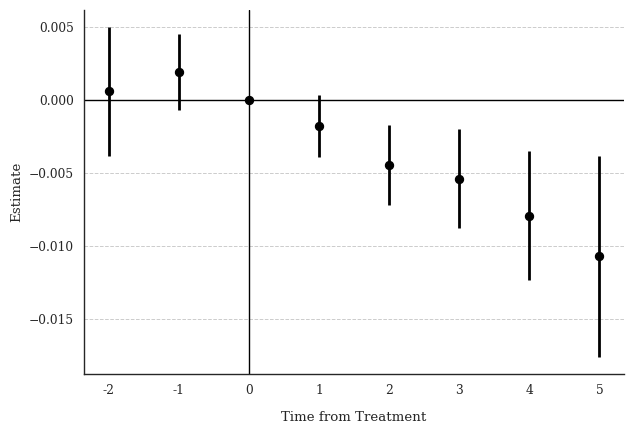

In [13]:
DID(df_rnp)

In [22]:
import scipy.stats as st

# Les valeurs de votre test Placebo
estimate_placebo = 0.002573 
se_placebo =   0.001376

# 1. Calcul du Z-score
z_score = estimate_placebo / se_placebo

# 2. Calcul de la p-value bilatérale
p_value = 2 * (1 - st.norm.cdf(abs(z_score)))

print(f"Z-score : {z_score:.3f}")
print(f"P-value du Placebo : {p_value:.3f}")

Z-score : 1.870
P-value du Placebo : 0.061


### RP

In [15]:
df_rnp['codecommune'][(df_rnp['traitée']==1)&(df_rnp['Annee']<2002)].unique()

<ArrowStringArray>
['01058', '01083', '01188', '01258', '01274', '01412', '02201', '02256',
 '02279', '02286',
 ...
 '88109', '88262', '88269', '88380', '88430', '88462', '89092', '89134',
 '89351', '89353']
Length: 846, dtype: str

In [16]:
df_rp['codecommune'][(df_rp['traitée']==1)&(df_rp['Annee']<2002)].unique()

<ArrowStringArray>
['01069', '01096', '01123', '01179', '01184', '01195', '01236', '01261',
 '01288', '01334',
 ...
 '89405', '89426', '89439', '90017', '90058', '91378', '91544', '95308',
 '95523', '95592']
Length: 865, dtype: str

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.002460 0.001085 -0.004587 -0.000334 51755.0     1518.0 51755.0       1518.0
            Effect_2 -0.003066 0.001362 -0.005736 -0.000397 40981.0     1414.0 40981.0       1414.0
            Effect_3 -0.002126 0.001706 -0.005471  0.001218 30620.0     1254.0 30620.0       1254.0
            Effect_4 -0.003873 0.002199 -0.008182  0.000436 20421.0     1038.0 20421.0       1038.0
            Effect_5 -0.001557 0.003353 -0.008128  0.005014 10134.0      564.0 10134.0        564.0
Average_Total_Effect -0.002701 0.001399 -0.005443  0.000040 56035.0     5788.0 56035.0       5788.0
           Placebo_1  0.002573 0.001376 -0.000124  0.005270 40510.0      951.0 40510.0        951.0
           Placebo_2  0.001899 0.002639 -0.003274  0.007072 19755.0      375.0 19755.0        375.0
Test of joint nullity of the effec

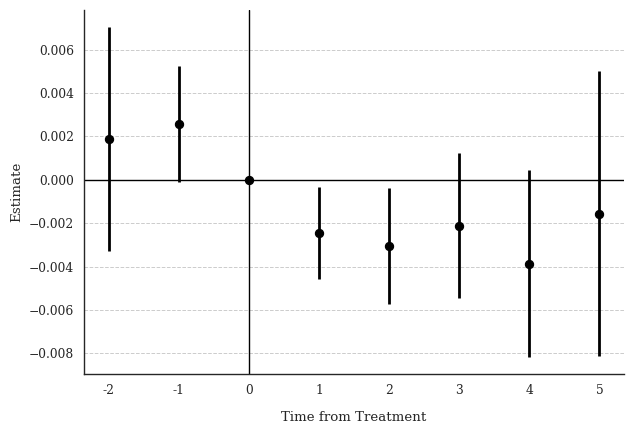

In [17]:
DID(df_rp)

### UI

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.001282 0.001998 -0.002634 0.005197 15958.0      295.0 15958.0        295.0
            Effect_2 -0.000166 0.002568 -0.005200 0.004868 12692.0      277.0 12692.0        277.0
            Effect_3 -0.000058 0.003407 -0.006734 0.006619  9516.0      252.0  9516.0        252.0
            Effect_4 -0.002058 0.004392 -0.010666 0.006551  6365.0      213.0  6365.0        213.0
            Effect_5 -0.006135 0.006622 -0.019113 0.006843  3181.0      114.0  3181.0        114.0
Average_Total_Effect -0.000713 0.002733 -0.006070 0.004645 16816.0     1151.0 16816.0       1151.0
           Placebo_1  0.000711 0.002259 -0.003717 0.005139 12593.0      180.0 12593.0        180.0
           Placebo_2  0.005017 0.005592 -0.005944 0.015977  6215.0       63.0  6215.0         63.0
Test of joint nullity of the effects: p-val

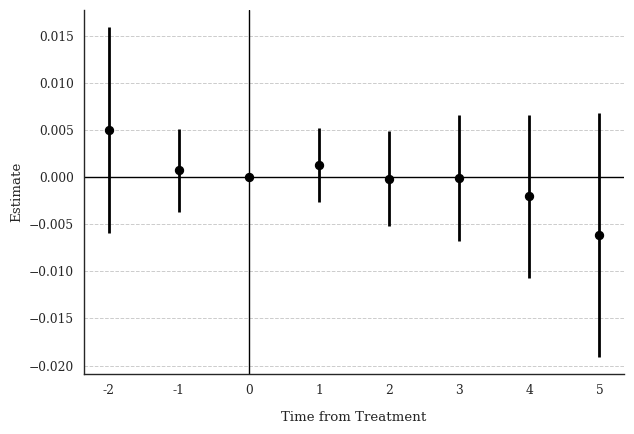

In [18]:
DID(df_ui)

### UD

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI      N  Switchers    N.w  Switchers.w
            Effect_1 -0.010371 0.007236 -0.024554  0.003812 2779.0       14.0 2779.0         14.0
            Effect_2 -0.023994 0.011522 -0.046576 -0.001411 2771.0       14.0 2771.0         14.0
            Effect_3 -0.011863 0.019960 -0.050984  0.027258 2078.0       12.0 2078.0         12.0
            Effect_4 -0.013087 0.022556 -0.057296  0.031121 1387.0       11.0 1387.0         11.0
            Effect_5 -0.023616 0.029410 -0.081258  0.034026  695.0        7.0  695.0          7.0
Average_Total_Effect -0.016082 0.014362 -0.044231  0.012068 3511.0       58.0 3511.0         58.0
           Placebo_1 -0.008856 0.009924 -0.028306  0.010594 2076.0        7.0 2076.0          7.0
           Placebo_2 -0.040914 0.014642 -0.069611 -0.012217 1379.0        3.0 1379.0          3.0
Test of joint nullity of the effects: p-value = 0.00

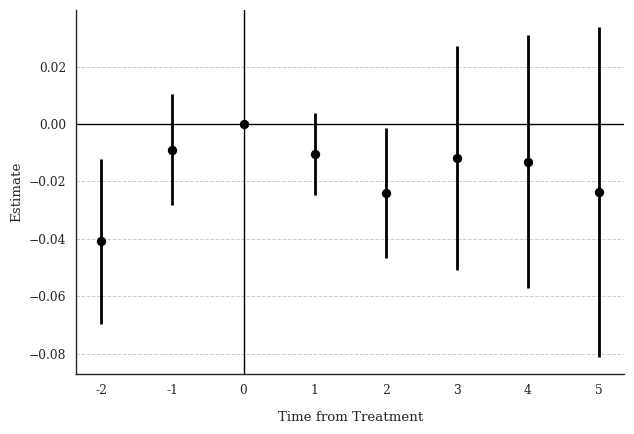

In [19]:
DID(df_ud)

In [20]:
df_test = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_rnp.csv", index_col=0)
df_test['codecommune'] = df_test['codecommune'].astype(str).str.zfill(5)

C:\Users\yancr\AppData\Local\Temp\ipykernel_8672\1623403117.py:1: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_rnp.csv", index_col=0)


In [21]:
df_test[df_test['total_equipements']>0]

,codecommune,Annee,pop,propf,prop014,prop1539,prop4059,prop60p,petranger,pcapi,...,pbac,psup,revmoy,vote_EG_pres,abstention_pres,vote_RN_pres,vote_EG_leg,abstention_leg,vote_RN_leg,total_equipements
22,01001,2017,776,0.498688,0.209974,0.217848,0.370079,0.202100,0.010309,0.297386,...,0.430631,0.243243,19859.061,0.136970,0.153846,0.254545,0.096736,0.436455,0.181009,1.0
23,01001,2018,771,0.501976,0.210804,0.206851,0.380764,0.201581,0.008997,0.267974,...,0.434705,0.241503,20854.352,NaN,NaN,NaN,NaN,NaN,NaN,1.0
24,01001,2019,779,0.501323,0.211640,0.195767,0.391534,0.201058,0.007702,0.237942,...,0.436945,0.238011,21015.090,NaN,NaN,NaN,NaN,NaN,NaN,1.0
25,01001,2020,781,0.504648,0.212483,0.184595,0.402390,0.200531,0.006410,0.207668,...,0.440917,0.236332,21443.418,NaN,NaN,NaN,NaN,NaN,NaN,1.0
26,01001,2021,784,0.506667,0.213333,0.173333,0.413333,0.200000,0.006394,0.177215,...,0.444056,0.234266,21529.191,NaN,NaN,NaN,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323147,90096,2022,273,0.397727,0.230114,0.238636,0.383523,0.147727,0.047138,0.890909,...,0.604082,0.383673,20949.492,0.160000,0.164609,0.390000,0.164062,0.456790,0.328125,1.0
323173,90101,2020,238,0.521429,0.035714,0.250000,0.342857,0.371429,0.007937,0.820513,...,0.278846,0.139423,16277.682,NaN,NaN,NaN,NaN,NaN,NaN,1.0
323174,90101,2021,233,0.519031,0.024221,0.245675,0.339100,0.391003,0.007968,0.941176,...,0.279621,0.137441,15770.765,NaN,NaN,NaN,NaN,NaN,NaN,1.0
323175,90101,2022,229,0.513605,0.013605,0.241497,0.336735,0.408163,0.008000,1.000000,...,0.287037,0.138889,15502.554,0.120513,0.184615,0.519231,0.141304,0.532995,0.358696,1.0
